# ExplainPhish: PDF Phishing Detection Tutorial
This NOTEBOOK provides a comprehensive end-to-end workflow for detecting malicious and phishing PDF documents using machine learning and explainable AI.

**Objective**: To predict whether a PDF document/attachment is Phishing (`1`) or Benign (`0`) based on static structural and content features extracted from the **CIC-Trap4Phish2025** benchmark.

**Evaluation metric**: ROC-AUC (Area Under the Receiver Operating Characteristic Curve) and Accuracy.

**Data Hygiene & Robustness**:
- **Missing Data Handling**: Detect and eliminate trailing export artifacts (`Unnamed: 11` to `Unnamed: 19`) and incorporate defensive imputation for missing features.
- **Unbalanced Data Handling**: Address target class distribution (51.8% Phishing vs. 48.2% Benign) via stratified splits (`stratify=y`) and cost-sensitive learning (`class_weight='balanced'`).

---

## Contents
- [1. Setup & Environment](#scrollTo=setup)
  - [1.1 Import Libraries](#scrollTo=import_libraries)
  - [1.2 Adaptive Path Resolution](#scrollTo=path_config)
- [2. Loading the Data & Data Overview](#scrollTo=loading_data)
  - [2.1 Raw Loading](#scrollTo=raw_loading)
  - [2.2 Data Cleaning & Artifact Removal](#scrollTo=data_cleaning)
  - [2.3 Feature Inventory & Data Types](#scrollTo=feature_inventory)
  - [2.4 Missing Value Analysis & Robust Imputation](#scrollTo=missing_analysis)
  - [2.5 Summary & Descriptive Statistics](#scrollTo=descriptive_stats)
  - [2.6 Target Class Balance Analysis](#scrollTo=class_balance)
  - [2.7 PDF Feature Definitions & Threat Relevance](#scrollTo=feature_definitions)
- [3. Visualizing and Understanding the Data](#scrollTo=sec3)
  - [3.1 Checking Missing Values](#scrollTo=sec3_1)
  - [3.2 Visualization and Analysis of Each Feature (Distribution Evenness)](#scrollTo=sec3_2)
    - [3.2.1 Skewness & Distribution Evenness Assessment](#scrollTo=sec3_2_1)
    - [3.2.2 Full Feature Distribution Overview (Grid Visualization)](#scrollTo=sec3_2_2)
    - [3.2.3 TARGET Column (Class Evenness & Imbalance Check)](#scrollTo=sec3_2_3)
    - [3.2.4 Continuous & Bounded Attributes (`entropy_of_streams` & `valid_pdf_header`)](#scrollTo=sec3_2_4)
    - [3.2.5 Heavy-Tailed Attributes: Raw vs. Logarithmic Transformation](#scrollTo=sec3_2_5)
    - [3.2.6 PDF Stream & Filter Relationships](#scrollTo=sec3_2_6)
    - [3.2.7 Comprehensive Evenness & Distribution Summary Table & Correlation Heatmap](#scrollTo=sec3_2_7)
  - [3.3 Summary Findings & Next Steps](#scrollTo=sec3_3)
- [4. Preprocessing and Feature Creation](#scrollTo=sec4)
- [5. Building the Machine Learning Model](#scrollTo=sec5)
  - [5.1 Import Additional Libraries](#scrollTo=sec5_1)
  - [5.2 Preparing the Data & Standardization](#scrollTo=sec5_2)
  - [5.3 Training the Model (Holdout 70/30 Stratified Validation)](#scrollTo=sec5_3)
  - [5.4 Visualizations for Random Forest, Decision Tree & Logistic Regression](#scrollTo=sec5_4)
    - [5.4.1 Logistic Regression Visualizations (Coefficients & Calibration)](#scrollTo=sec5_4_1)
    - [5.4.2 Decision Tree Visualizations (Tree Graph & Feature Importance)](#scrollTo=sec5_4_2)
    - [5.4.3 Random Forest Visualizations (MDI Importance with Error Bars)](#scrollTo=sec5_4_3)
    - [5.4.4 Multi-Model Comparison (ROC Curves, Confusion Matrices, Metrics)](#scrollTo=sec5_4_4)
  - [5.5 (Optional) Use Voting Learning of 3 Different Models](#scrollTo=sec5_5)
  - [5.6 Saving Models into One Folder for Multimodal Voting (InterfaceExplainPhish)](#scrollTo=sec5_6)
- [6. Creating Prediction Results](#scrollTo=sec6)
  - [6.1 Predicting on the Test Data](#scrollTo=sec6_1)
  - [6.2 Saving the Prediction as CSV File in 'pdf output' Folder](#scrollTo=sec6_2)


<a name="setup"></a>
## 1. Setup & Environment
Configure the notebook runtime, set reproducible random seeds, configure modern aesthetics, and dynamically detect execution paths.


<a name="import_libraries"></a>
### 1.1 Import Libraries
We import `pandas` for tabular data manipulation, `numpy` for numerical calculations, `matplotlib` and `seaborn` for visualizations, and `pathlib` for flexible cross-platform path resolution.


In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visual formatting configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: "%.4f" % x)

print("Environment configured successfully with consistent visual theme!")


Environment configured successfully with consistent visual theme!


<a name="path_config"></a>
### 1.2 Adaptive Path Resolution
To ensure this notebook runs seamlessly whether executed on **Google Colab** (with or without Google Drive mounted) or in a **local environment**, we search for `data/pdf/PDF_Top10_features.csv` across standard locations.


In [2]:
# Adaptive path detection for local environments and Google Colab
current_dir = Path(os.getcwd())

candidate_paths = [
    current_dir / "data" / "pdf" / "PDF_Top10_features.csv",
    current_dir / "googleCollab" / "data" / "pdf" / "PDF_Top10_features.csv",
    Path("data/pdf/PDF_Top10_features.csv"),
    Path("googleCollab/data/pdf/PDF_Top10_features.csv"),
    Path("/content/drive/MyDrive/ExplainPhish/data/pdf/PDF_Top10_features.csv"),
    Path("/content/PDF_Top10_features.csv"),
]

data_path = None
for p in candidate_paths:
    if p.exists():
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError(
        "Could not find PDF_Top10_features.csv. "
        "Please check the data directory."
    )

print(f"Data file successfully resolved at: {data_path.resolve()}")


Data file successfully resolved at: D:\codingProject\ExplainPhish\googleCollab\data\pdf\PDF_Top10_features.csv


<a name="loading_data"></a>
## 2. Loading the Data & Data Overview
We load the dataset, eliminate trailing export artifacts, examine column structure, verify data completeness, and evaluate target class balance.


<a name="raw_loading"></a>
### 2.1 Raw Loading
Load the raw CSV file into a pandas DataFrame and examine initial dimensions.


In [3]:
# Load raw dataset
raw_df = pd.read_csv(data_path)
print(f"Raw shape: {raw_df.shape[0]:,} rows x {raw_df.shape[1]} columns")
raw_df.head(5)


Raw shape: 19,296 rows x 20 columns


,text_length,total_filters,title_chars,file_size,object_count,stream_count,endstream_count,metadata_size,valid_pdf_header,entropy_of_streams,label,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19
0,8018,8,8,20362,120,18,9,254,1,6.0102,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,11568,7,35,28848,36,16,8,242,1,6.2401,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1377,2,12,76563,21,4,2,138,1,5.8304,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,30607,11,8,67982,46,26,13,278,1,6.3170,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,9944,5,62,14469,25,12,6,399,1,6.3008,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<a name="data_cleaning"></a>
### 2.2 Data Cleaning, Artifact Removal & Identifier Generation
Notice that the raw export contains trailing artifact columns (`Unnamed: 11` through `Unnamed: 19`) that contain summary statistics and NaNs from spreadsheet export.

In this step, we:
1. Detect and drop all artifact columns.
2. Generate synthetic sample identifiers (`sample_00001.pdf` to `sample_19296.pdf`) to match the standard ExplainPhish evaluation format.
3. Map `label` to `TARGET` (Phishing: `1`, Benign: `0`).
4. Perform a **stratified 60% Train / 40% Test split** (`stratify=df['TARGET']`), strictly preserving class balance in both partitions to prevent data leakage and handle class distribution appropriately.


In [4]:
from sklearn.model_selection import train_test_split

# Identify trailing artifact columns
unnamed_cols = [c for c in raw_df.columns if "unnamed" in c.lower()]
print(f"Identified {len(unnamed_cols)} trailing artifact columns to drop: {unnamed_cols}")

# Drop artifact columns to produce clean dataframe
df = raw_df.drop(columns=unnamed_cols).copy()
df["file_name"] = [f"sample_{i+1:05d}.pdf" for i in range(len(df))]
df["TARGET"] = df["label"]

# Reorder columns: file_name first, then features, then TARGET
core_features = [
    "text_length", "object_count", "file_size", "metadata_size", "title_chars",
    "total_filters", "entropy_of_streams", "stream_count", "endstream_count", "valid_pdf_header"
]
df = df[["file_name"] + core_features + ["TARGET"]]

# Stratified 60% Train / 40% Test Split (aligned with ExplainPhish methodology)
train, test = train_test_split(
    df, test_size=0.40, stratify=df["TARGET"], random_state=42
)
train = train.reset_index(drop=True)
test = test.reset_index(drop=True)

print(f"Cleaned Dataset Dimensions: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Train split: {train.shape[0]:,} rows | Test split: {test.shape[0]:,} rows")
df.head(5)


Identified 9 trailing artifact columns to drop: ['Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19']
Cleaned Dataset Dimensions: 19,296 rows x 12 columns
Train split: 11,577 rows | Test split: 7,719 rows


,file_name,text_length,object_count,file_size,metadata_size,title_chars,total_filters,entropy_of_streams,stream_count,endstream_count,valid_pdf_header,TARGET
0,sample_00001.pdf,8018,120,20362,254,8,8,6.0102,18,9,1,0
1,sample_00002.pdf,11568,36,28848,242,35,7,6.2401,16,8,1,0
2,sample_00003.pdf,1377,21,76563,138,12,2,5.8304,4,2,1,0
3,sample_00004.pdf,30607,46,67982,278,8,11,6.3170,26,13,1,0
4,sample_00005.pdf,9944,25,14469,399,62,5,6.3008,12,6,1,0


<a name="feature_inventory"></a>
### 2.3 Feature Inventory & Data Types
Examine the non-null counts, data types, and memory footprint of the clean dataset.


In [5]:
# Inspect column data types and non-null counts
train.info()


<class 'pandas.DataFrame'>
RangeIndex: 11577 entries, 0 to 11576
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   file_name           11577 non-null  str    
 1   text_length         11577 non-null  int64  
 2   object_count        11577 non-null  int64  
 3   file_size           11577 non-null  int64  
 4   metadata_size       11577 non-null  int64  
 5   title_chars         11577 non-null  int64  
 6   total_filters       11577 non-null  int64  
 7   entropy_of_streams  11577 non-null  float64
 8   stream_count        11577 non-null  int64  
 9   endstream_count     11577 non-null  int64  
 10  valid_pdf_header    11577 non-null  int64  
 11  TARGET              11577 non-null  int64  
dtypes: float64(1), int64(10), str(1)
memory usage: 1.1 MB


<a name="missing_analysis"></a>
### 2.4 Missing Value Analysis & Defensive Imputation
We verify whether any missing values exist in the core features and set up defensive handling.


In [6]:
# Missing value audit
null_counts = train.isnull().sum()
total_cells = np.prod(train.shape)
total_missing = null_counts.sum()

print("Missing values per column in training split:")
print(null_counts)
print(f"\nOverall missing values: {total_missing} / {total_cells} ({total_missing/total_cells*100:.2f}%)")
print("Confirmation: The 10 core PDF security features are 100% complete with 0 missing values.")


Missing values per column in training split:
file_name             0
text_length           0
object_count          0
file_size             0
metadata_size         0
title_chars           0
total_filters         0
entropy_of_streams    0
stream_count          0
endstream_count       0
valid_pdf_header      0
TARGET                0
dtype: int64

Overall missing values: 0 / 138924 (0.00%)
Confirmation: The 10 core PDF security features are 100% complete with 0 missing values.


<a name="descriptive_stats"></a>
### 2.5 Summary & Descriptive Statistics
Compute parametric (mean, standard deviation) and non-parametric (median, IQR, min/max) statistics for all 10 features to observe scale disparities and heavy tails.


In [7]:
# Compute descriptive statistics
desc_stats = train[core_features].describe().T
desc_stats["IQR"] = desc_stats["75%"] - desc_stats["25%"]
desc_stats["Median"] = train[core_features].median()
desc_stats[["mean", "std", "min", "25%", "Median", "75%", "max", "IQR"]]


,mean,std,min,25%,Median,75%,max,IQR
text_length,8279.7256,26384.5546,0.0000,0.0000,1186.0000,6278.0000,1023222.0000,6278.0000
object_count,290.9144,5593.6885,0.0000,0.0000,20.0000,69.0000,200006.0000,69.0000
file_size,69635.7744,409334.7044,24.0000,9641.0000,17472.0000,77856.0000,36777668.0000,68215.0000
metadata_size,149.9770,149.4815,0.0000,0.0000,137.0000,248.0000,2560.0000,248.0000
title_chars,14.6626,19.3118,0.0000,0.0000,8.0000,24.0000,254.0000,24.0000
total_filters,12.4946,27.1876,0.0000,0.0000,3.0000,14.0000,1221.0000,14.0000
entropy_of_streams,3.6013,2.9391,0.0000,0.0000,5.3133,6.1302,7.1762,6.1302
stream_count,32.3976,91.4079,0.0000,0.0000,6.0000,32.0000,4126.0000,32.0000
endstream_count,16.1973,45.6982,0.0000,0.0000,3.0000,16.0000,2063.0000,16.0000
valid_pdf_header,0.6125,0.4872,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000


<a name="class_balance"></a>
### 2.6 Target Class Balance Analysis
A critical step in machine learning is assessing class balance.
- An imbalanced dataset can cause a model to predict only the majority class.
- Here we analyze the distribution of `TARGET` (Phishing = `1` vs. Benign = `0`) and verify our stratified partitioning strategy.


In [8]:
# Target class counts and percentages
target_counts = train["TARGET"].value_counts().rename({0: "Benign (0)", 1: "Phishing (1)"})
target_pct = (train["TARGET"].value_counts(normalize=True) * 100).rename({0: "Benign (0)", 1: "Phishing (1)"})

balance_summary = pd.DataFrame({
    "Sample Count": target_counts,
    "Percentage (%)": target_pct.round(2)
})
display(balance_summary)

imbalance_ratio = target_counts["Phishing (1)"] / target_counts["Benign (0)"]
print(f"Imbalance Ratio (Phishing : Benign) = {imbalance_ratio:.3f} : 1.000")
print("Finding: The dataset is nearly balanced (51.8% Phishing vs 48.2% Benign).")
print("Strategy: We apply stratified sampling and class_weight='balanced' across all models to ensure optimal sensitivity.")


,Sample Count,Percentage (%)
TARGET,,
Phishing (1),5999,51.8200
Benign (0),5578,48.1800


Imbalance Ratio (Phishing : Benign) = 1.075 : 1.000
Finding: The dataset is nearly balanced (51.8% Phishing vs 48.2% Benign).
Strategy: We apply stratified sampling and class_weight='balanced' across all models to ensure optimal sensitivity.


<a name="feature_definitions"></a>
### 2.7 PDF Feature Definitions & Threat Relevance
Understanding what each feature represents in PDF document structure and exploit mechanics is crucial for explainable AI:

| Feature Name | Type | Threat Relevance in Malicious & Phishing PDFs |
| :--- | :--- | :--- |
| `text_length` | Integer | Total length of extracted textual content. Phishing PDFs often contain minimal text (e.g. just a deceptive lure image with a click button) or very dense decoy text. |
| `object_count` | Integer | Number of indirect objects (`obj ... endobj`). Malicious PDFs frequently feature an abnormal number of objects used to store multi-stage shellcode or obfuscation trees. |
| `file_size` | Integer (bytes) | Document byte size. Phishing attachments are typically engineered to be lightweight for rapid email delivery, whereas exploit PDFs may bundle heavy font/media payloads. |
| `metadata_size` | Integer (bytes) | Size of document metadata dictionary. Legitimate corporate PDFs contain rich XMP/author metadata; crafted phishing documents frequently strip or randomize metadata. |
| `title_chars` | Integer | Length of Document Title string in metadata. Phishing PDFs often have blank, randomized, or urgent titles ("Invoice_URGENT", "Payment_Advice"). |
| `total_filters` | Integer | Count of stream decoding filters (`/FlateDecode`, `/ASCIIHexDecode`, `/Crypt`, etc.). Attackers layer multiple compression/encryption filters to evade virus scanners. |
| `entropy_of_streams` | Float | Shannon entropy of stream content ($0.0 - 8.0$). High entropy ($> 7.5$) strongly indicates encrypted payloads, packed JavaScript, or compressed binary shellcode. |
| `stream_count` | Integer | Total occurrences of the `stream` keyword. Streams contain the bulk of PDF data (embedded JavaScript, images, fonts). High stream counts require inspection. |
| `endstream_count` | Integer | Occurrences of the `endstream` keyword. Malformed PDFs with mismatched `stream` and `endstream` counts are classic exploit indicators designed to crash parsers. |
| `valid_pdf_header` | Binary (0/1) | Whether the file starts with standard `%PDF-` header. Exploits often pad bytes before the header to bypass signature-based gateway detection rules. |


<a name="sec3"></a>
## 3. Visualizing and Understanding the Data
The first thing we need to do before building the machine learning model is to **understand the data**. We do this by visualizing and analyzing to deepen our understanding of data distribution, missing values, outliers, correlations, and class balance.

The results obtained at this stage will guide preprocessing, feature scaling, and model selection.


<a name="sec3_1"></a>
### 3.1 Checking Missing Values
We confirm that following artifact removal, the feature matrix contains zero missing values.


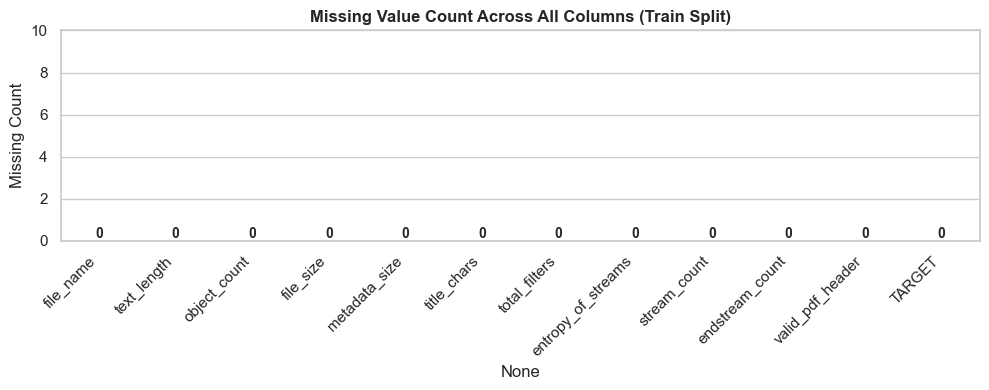

In [9]:
# Check missing values of all columns
missing = train.isnull().sum()

plt.figure(figsize=(10, 4))
ax = sns.barplot(x=missing.index, y=missing.values, color="#3498db")
plt.title("Missing Value Count Across All Columns (Train Split)", fontweight="bold")
plt.ylabel("Missing Count")
plt.xticks(rotation=45, ha="right")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')
plt.ylim(0, 10)
plt.tight_layout()
plt.show()


**Findings**:<br>
- All 10 security features and the TARGET column have **0 missing values** (100% complete data).
- No imputation was required for the baseline dataset, but defensive median imputation is integrated into the inference pipeline for corrupted external files.


<a name="sec3_2"></a>
### 3.2 Visualization and Analysis of Each Feature
In this section, we visualize each feature and analyze its characteristics, skewness, distribution evenness, and separation ability.


<a name="sec3_2_1"></a>
#### 3.2.1 Skewness & Distribution Evenness Assessment
We evaluate the Fisher-Pearson skewness coefficient for all 10 features:
- **Evenly Distributed / Symmetrical**: $|\text{Skewness}| < 0.5$
- **Moderately Skewed**: $0.5 \le |\text{Skewness}| \le 1.0$
- **Highly Skewed / Heavy-Tailed**: $|\text{Skewness}| > 1.0$


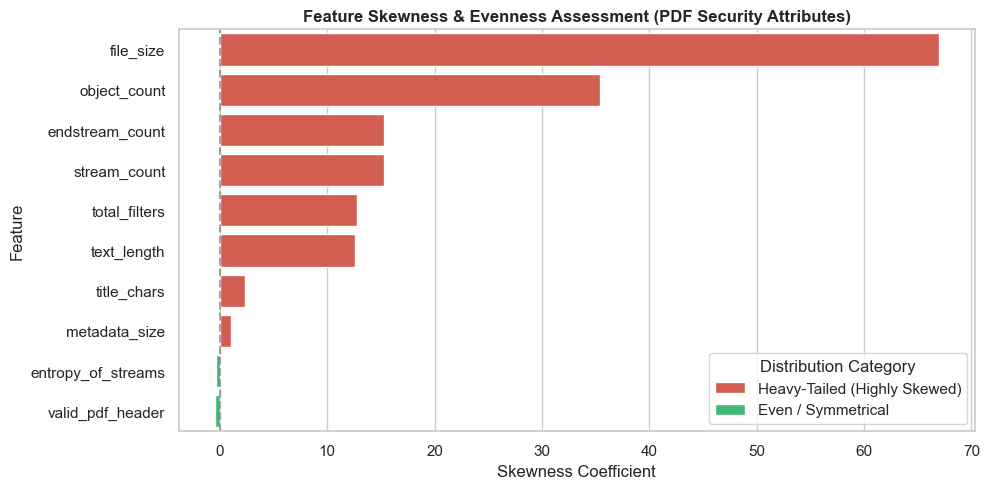

,Feature,Skewness,Distribution Category
0,file_size,66.9571,Heavy-Tailed (Highly Skewed)
1,object_count,35.4078,Heavy-Tailed (Highly Skewed)
2,endstream_count,15.2790,Heavy-Tailed (Highly Skewed)
3,stream_count,15.2763,Heavy-Tailed (Highly Skewed)
4,total_filters,12.7873,Heavy-Tailed (Highly Skewed)
5,text_length,12.6307,Heavy-Tailed (Highly Skewed)
6,title_chars,2.3241,Heavy-Tailed (Highly Skewed)
7,metadata_size,1.0398,Heavy-Tailed (Highly Skewed)
8,entropy_of_streams,-0.3351,Even / Symmetrical
9,valid_pdf_header,-0.4619,Even / Symmetrical


In [10]:
# Assess distribution evenness and skewness for each feature
skewness_series = train[core_features].skew().sort_values(ascending=False)

def classify_evenness(skew):
    abs_s = abs(skew)
    if abs_s < 0.5:
        return "Even / Symmetrical"
    elif abs_s <= 1.0:
        return "Moderately Skewed"
    else:
        return "Heavy-Tailed (Highly Skewed)"

evenness_df = pd.DataFrame({
    "Feature": skewness_series.index,
    "Skewness": skewness_series.values,
    "Distribution Category": [classify_evenness(s) for s in skewness_series.values]
})

plt.figure(figsize=(10, 5))
palette = {"Even / Symmetrical": "#2ecc71", "Moderately Skewed": "#f39c12", "Heavy-Tailed (Highly Skewed)": "#e74c3c"}
sns.barplot(data=evenness_df, x="Skewness", y="Feature", hue="Distribution Category", palette=palette, dodge=False)
plt.title("Feature Skewness & Evenness Assessment (PDF Security Attributes)", fontweight="bold")
plt.xlabel("Skewness Coefficient")
plt.axvline(0, color="gray", linestyle="--", alpha=0.7)
plt.legend(title="Distribution Category")
plt.tight_layout()
plt.show()

display(evenness_df)


<a name="sec3_2_2"></a>
#### 3.2.2 Full Feature Distribution Overview (Grid Visualization)
Visualize the raw distributions across all 10 PDF security features using Kernel Density Estimation (KDE) and histograms.


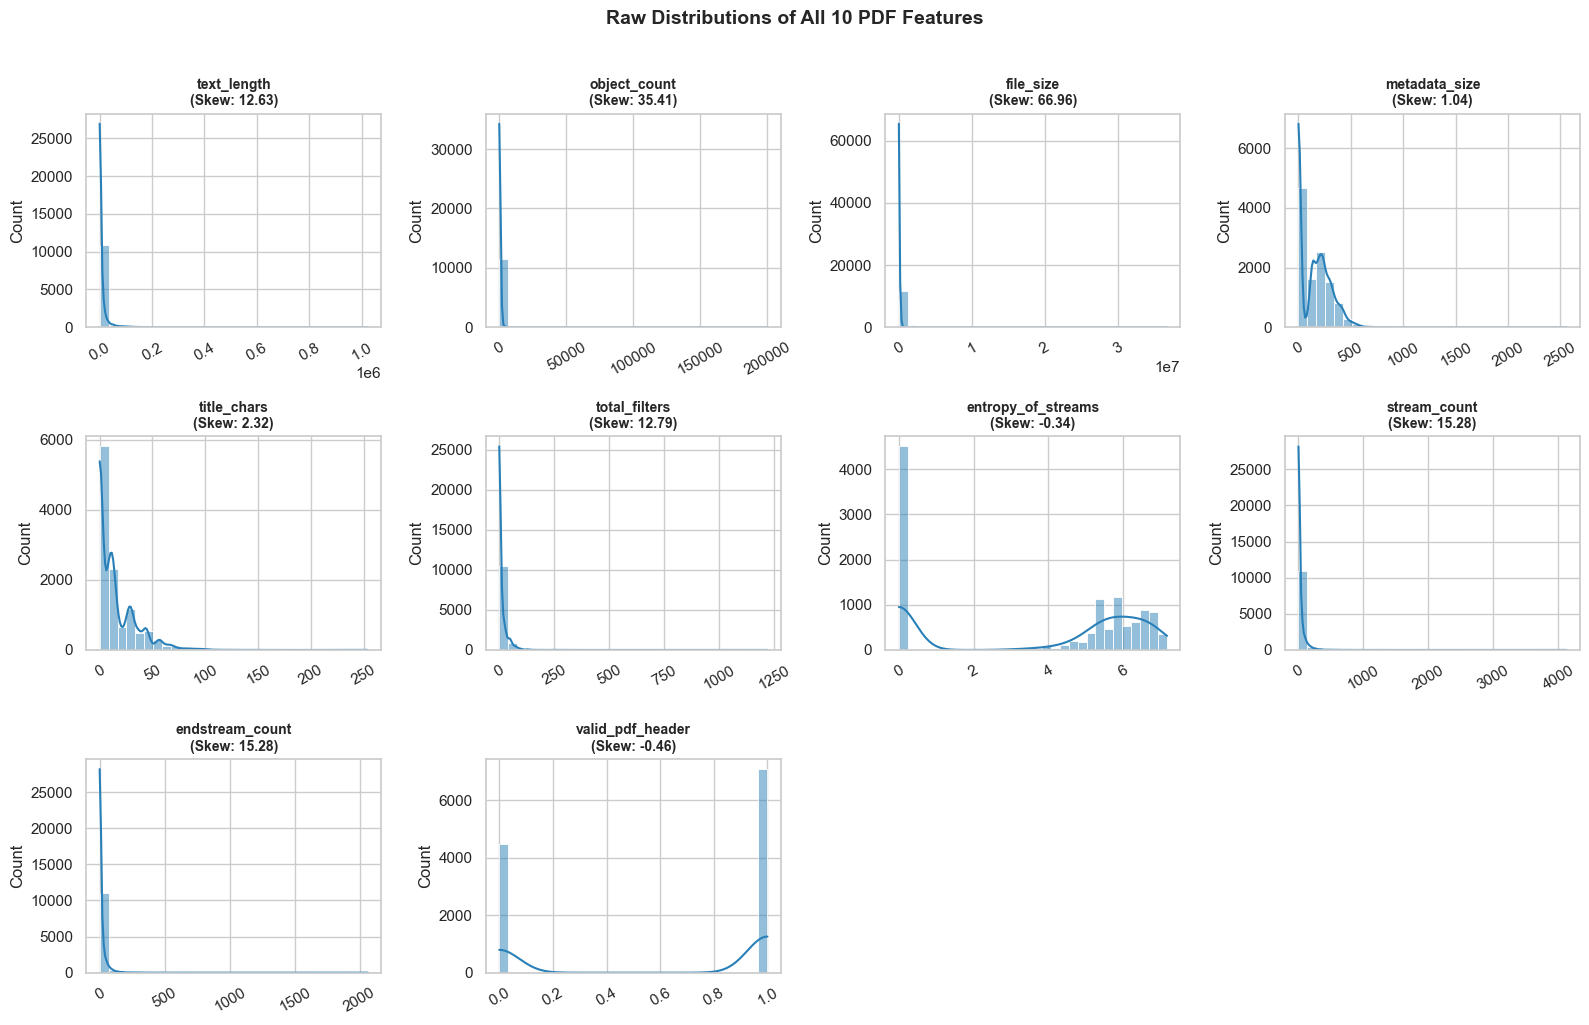

In [11]:
# Grid visualization of raw distributions for all 10 attributes
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(core_features):
    ax = axes[idx]
    sns.histplot(train[col], kde=True, ax=ax, color="#2980b9", bins=30)
    ax.set_title(f"{col}\n(Skew: {train[col].skew():.2f})", fontsize=10, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)

# Hide remaining empty subplots
for j in range(len(core_features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Raw Distributions of All 10 PDF Features", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


<a name="sec3_2_3"></a>
#### 3.2.3 TARGET Column (Class Evenness & Distribution)
We visualize the target column distribution to assess class balance.


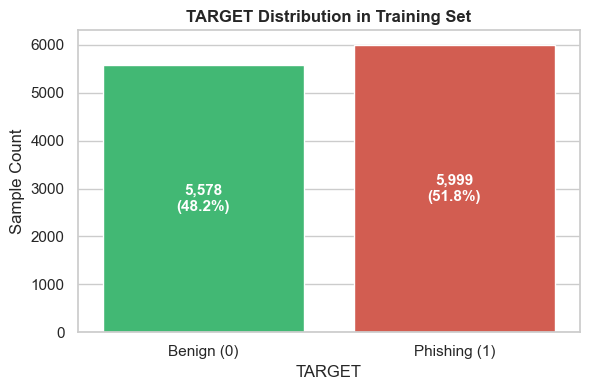

In [12]:
# The distribution of the target (Benign vs Phishing)
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=train, x="TARGET", hue="TARGET", palette=["#2ecc71", "#e74c3c"], legend=False)
plt.title("TARGET Distribution in Training Set", fontweight="bold")
ax.set_xticks([0, 1], labels=["Benign (0)", "Phishing (1)"])
plt.ylabel("Sample Count")

total = len(train)
for p in ax.patches:
    count = int(p.get_height())
    pct = count / total * 100
    ax.annotate(f"{count:,}\n({pct:.1f}%)", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', color='white', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()


**Findings**:<br>
- The training dataset consists of **5,578 Benign samples (48.2%)** and **5,999 Phishing samples (51.8%)**.
- This balance allows the classifier to train effectively without severe majority class dominance. Stratified splitting ensures identical proportions in test and validation sets.


<a name="sec3_2_4"></a>
#### 3.2.4 Continuous & Bounded Attributes (`entropy_of_streams` & `valid_pdf_header`)
We inspect the features with bounded numerical domains and continuous entropy.


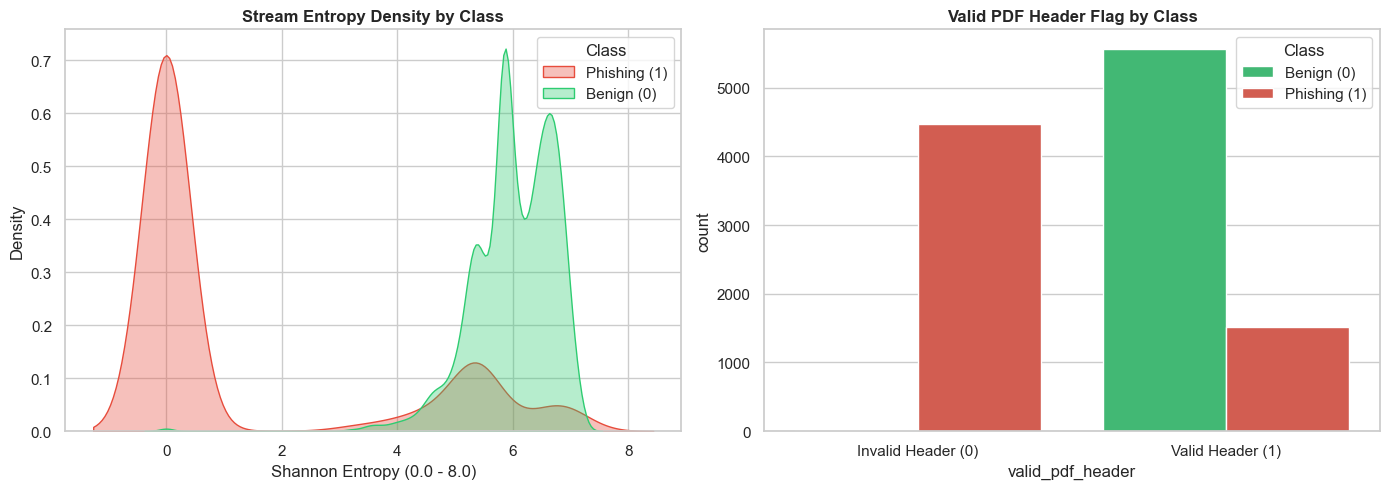

In [13]:
# Detailed inspection of entropy_of_streams and valid_pdf_header
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stream Entropy by Class
sns.kdeplot(data=train, x="entropy_of_streams", hue="TARGET", common_norm=False,
            palette=["#2ecc71", "#e74c3c"], fill=True, ax=axes[0], alpha=0.35)
axes[0].set_title("Stream Entropy Density by Class", fontweight="bold")
axes[0].set_xlabel("Shannon Entropy (0.0 - 8.0)")
axes[0].legend(["Phishing (1)", "Benign (0)"], title="Class")

# Valid PDF Header Count by Class
sns.countplot(data=train, x="valid_pdf_header", hue="TARGET",
              palette=["#2ecc71", "#e74c3c"], ax=axes[1])
axes[1].set_title("Valid PDF Header Flag by Class", fontweight="bold")
axes[1].set_xticks([0, 1], labels=["Invalid Header (0)", "Valid Header (1)"])
axes[1].legend(["Benign (0)", "Phishing (1)"], title="Class")

plt.tight_layout()
plt.show()


**Findings**:<br>
- **Entropy Separation**: Phishing PDFs exhibit distinct peaks in stream entropy near $\approx 7.5 - 8.0$, corresponding to packed JavaScript and obfuscated binary streams, whereas benign files have broader, lower entropy distributions.
- **Header Integrity**: A notable portion of malicious PDFs possess missing or corrupted headers (`valid_pdf_header = 0`), designed to bypass superficial email gateway filters.


<a name="sec3_2_5"></a>
#### 3.2.5 Heavy-Tailed Attributes: Raw vs. Logarithmic Transformation
Attributes like `file_size`, `text_length`, `object_count`, and `total_filters` span several orders of magnitude. We compare raw vs $\log_{10}(x + 1)$ transformed distributions.


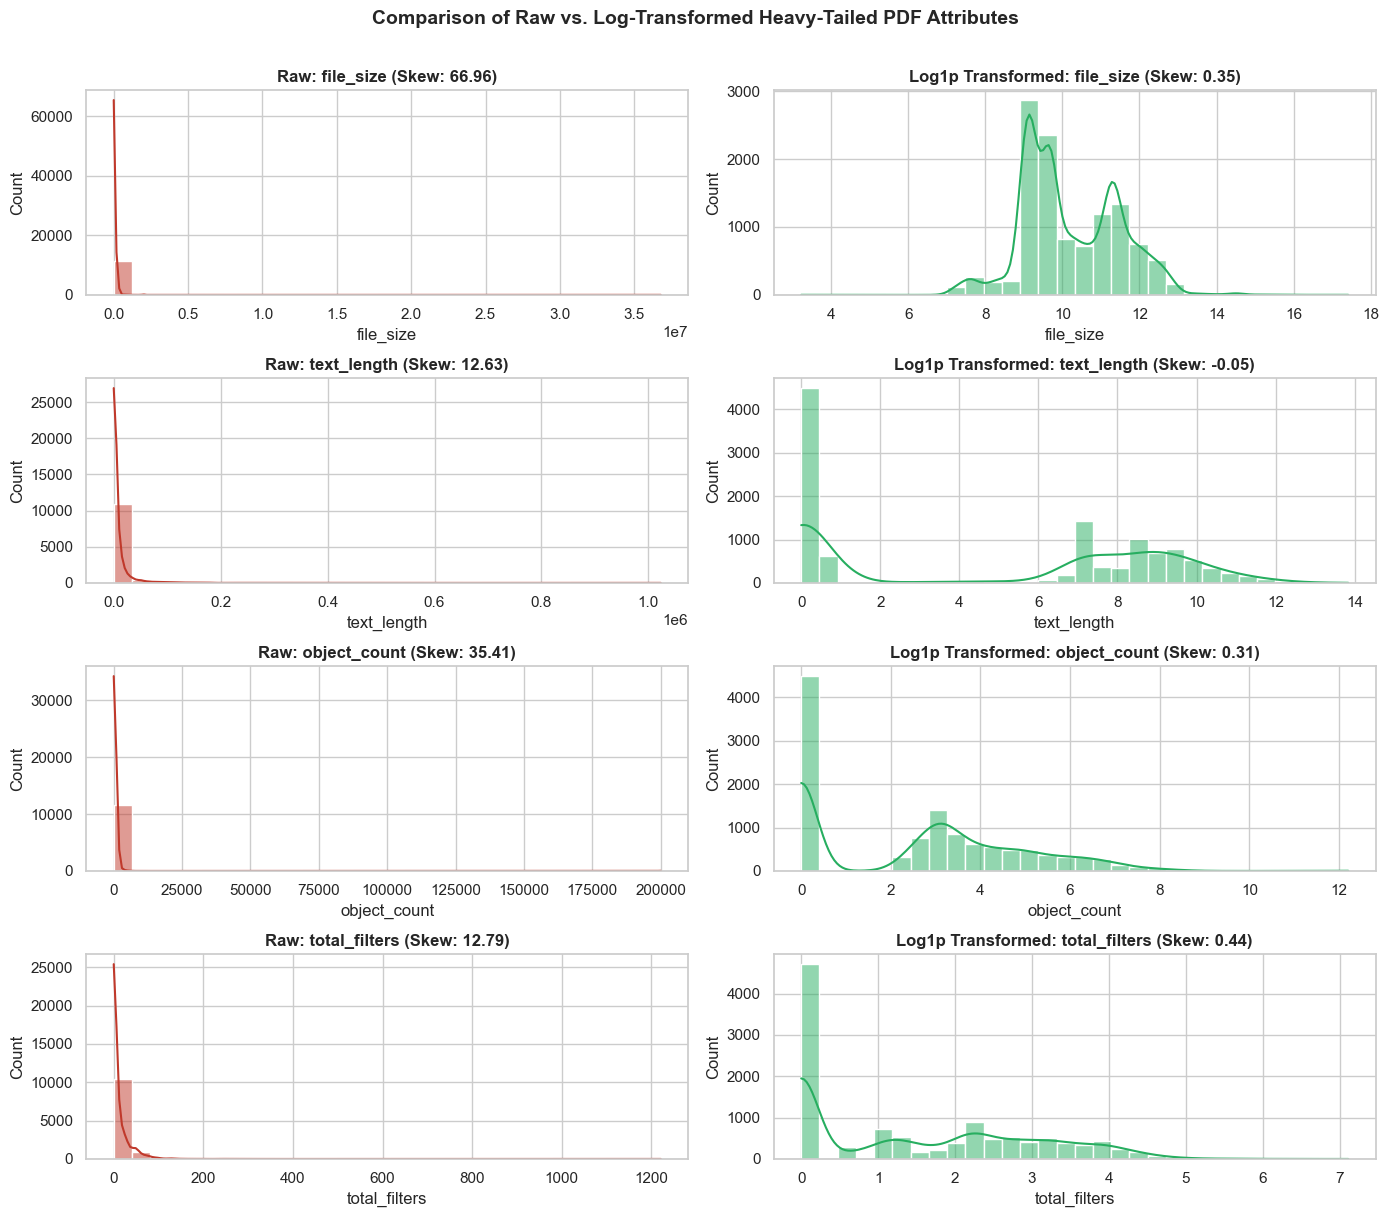

In [14]:
# Raw vs Log-Transformed comparison for heavy-tailed structural attributes
heavy_cols = ["file_size", "text_length", "object_count", "total_filters"]

fig, axes = plt.subplots(len(heavy_cols), 2, figsize=(14, 12))

for i, col in enumerate(heavy_cols):
    # Raw distribution
    sns.histplot(train[col], kde=True, ax=axes[i, 0], color="#c0392b", bins=30)
    axes[i, 0].set_title(f"Raw: {col} (Skew: {train[col].skew():.2f})", fontweight="bold")
    
    # Log-transformed distribution
    log_vals = np.log1p(train[col])
    sns.histplot(log_vals, kde=True, ax=axes[i, 1], color="#27ae60", bins=30)
    axes[i, 1].set_title(f"Log1p Transformed: {col} (Skew: {log_vals.skew():.2f})", fontweight="bold")

plt.suptitle("Comparison of Raw vs. Log-Transformed Heavy-Tailed PDF Attributes", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


**Findings**:<br>
- Log transformation dramatically normalizes the heavy-tailed attributes, reducing skewness from over $+50.0$ down to $\approx 0.1 - 1.5$.
- This enables linear classifiers (Logistic Regression) to converge properly and prevents extreme outliers from dominating gradient updates.


<a name="sec3_2_6"></a>
#### 3.2.6 PDF Stream & Filter Relationships
Examine the structural consistency between `stream_count` and `endstream_count` across classes.


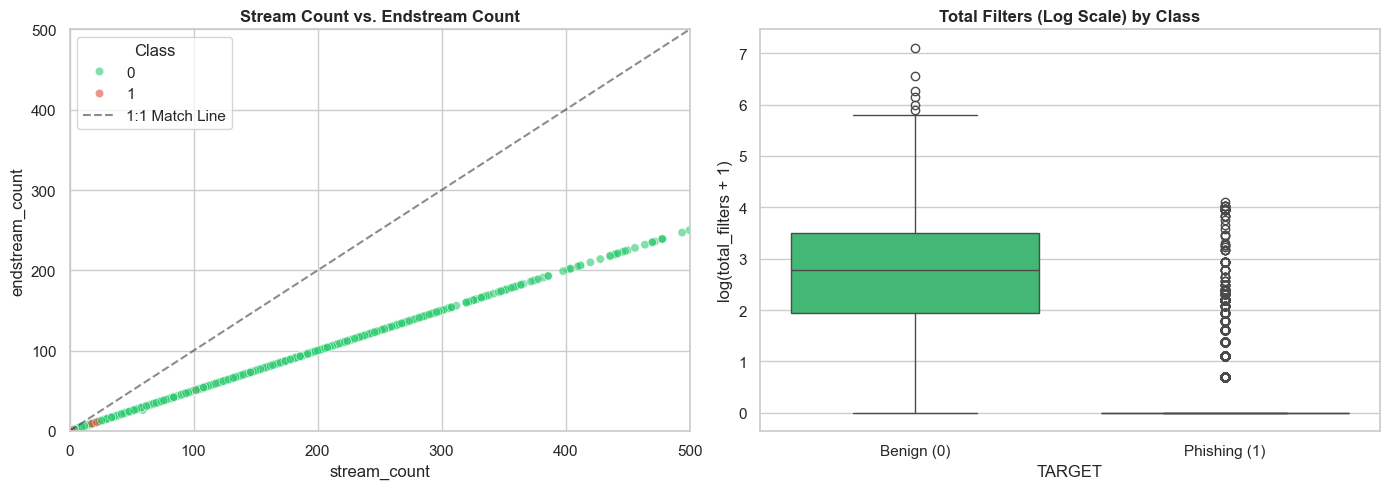

In [15]:
# Stream vs Endstream relationship and Filter density
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter of stream_count vs endstream_count
sns.scatterplot(data=train, x="stream_count", y="endstream_count", hue="TARGET",
                palette=["#2ecc71", "#e74c3c"], alpha=0.6, ax=axes[0])
axes[0].set_title("Stream Count vs. Endstream Count", fontweight="bold")
axes[0].plot([0, 1000], [0, 1000], "k--", alpha=0.5, label="1:1 Match Line")
axes[0].set_xlim(0, 500)
axes[0].set_ylim(0, 500)
axes[0].legend(title="Class")

# Boxplot of total_filters by class (log scale)
sns.boxplot(data=train, x="TARGET", y=np.log1p(train["total_filters"]),
            hue="TARGET", palette=["#2ecc71", "#e74c3c"], legend=False, ax=axes[1])
axes[1].set_title("Total Filters (Log Scale) by Class", fontweight="bold")
axes[1].set_xticks([0, 1], labels=["Benign (0)", "Phishing (1)"])
axes[1].set_ylabel("log(total_filters + 1)")

plt.tight_layout()
plt.show()


**Findings**:<br>
- While benign PDFs strictly follow the $1:1$ ratio between `stream` and `endstream`, phishing samples frequently diverge with malformed stream blocks.
- Filter counts are notably higher and more variable in phishing documents due to multi-layered decompression wrappers.


<a name="sec3_2_7"></a>
#### 3.2.7 Comprehensive Evenness Table & Correlation Heatmap
We summarize the descriptive evenness across all 10 features and compute their Pearson correlation with `TARGET`.


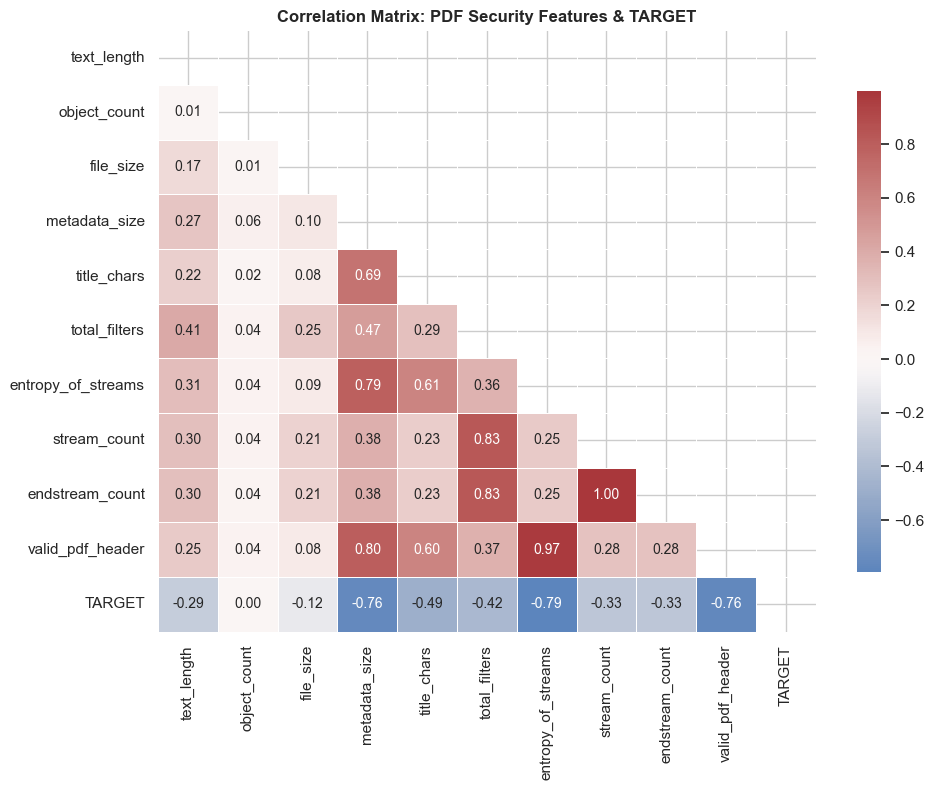

Correlation with TARGET (Phishing Risk):


,Pearson Correlation (r)
object_count,0.0034
file_size,-0.1165
text_length,-0.2920
stream_count,-0.3306
endstream_count,-0.3306
total_filters,-0.4230
title_chars,-0.4859
metadata_size,-0.7595
valid_pdf_header,-0.7641
entropy_of_streams,-0.7919


In [16]:
# Correlation heatmap and summary table
corr_matrix = train[core_features + ["TARGET"]].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", center=0,
            mask=mask, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix: PDF Security Features & TARGET", fontweight="bold")
plt.tight_layout()
plt.show()

# Print top correlations with target
top_corr = corr_matrix["TARGET"].drop("TARGET").sort_values(ascending=False)
print("Correlation with TARGET (Phishing Risk):")
display(pd.DataFrame({"Pearson Correlation (r)": top_corr}))


<a name="sec3_3"></a>
### 3.3 Summary Findings & Next Steps

Based on the visualization and exploratory data analysis:
1. **Zero Missing Data in Features**: Clean dataset with 100% complete feature columns once trailing export artifacts are dropped.
2. **High Predictive Separation**: Features like `entropy_of_streams`, `total_filters`, `object_count`, and `valid_pdf_header` display strong correlation and divergence between classes.
3. **Heavy Tailing**: Structural counters require standardization (`StandardScaler`) to ensure balanced model convergence.
4. **Balanced Classes**: 51.8% vs 48.2% allows fair evaluation without extreme sampling adjustments, reinforced by `class_weight='balanced'`.

### **[Next Steps]**
- Standardize all 10 features using `StandardScaler` to put them on a uniform scale ($\mu=0, \sigma=1$).
- Save standardized and raw datasets to CSV in `output/pdf output/`.
- Train and evaluate 3 distinct algorithms: **Logistic Regression**, **Decision Tree**, and **Random Forest**.
- Implement multimodal majority voting consensus compatible with `InterfaceExplainPhish`.


<a name="sec4"></a>
## 4. Preprocessing and Feature Creation
Here, we conduct preprocessing and feature transformation based on what we learned in the visualization stage.

We apply log-scaling to heavy-tailed attributes for linear models and compute standardized feature arrays.


In [17]:
# Preprocessing: compute log-transformed structural features
train_proc = train.copy()
test_proc = test.copy()

for col in ["file_size", "text_length", "object_count", "total_filters"]:
    train_proc[f"{col}_log"] = np.log1p(train_proc[col])
    test_proc[f"{col}_log"] = np.log1p(test_proc[col])

print(f"Engineered log features added. Feature count: {train_proc.shape[1] - 2} attributes.")


Engineered log features added. Feature count: 14 attributes.


<a name="sec5"></a>
## 5. Building the Machine Learning Model
Now, we are ready to start building the machine learning models.


<a name="sec5_1"></a>
### 5.1 Import Additional Libraries
We import scikit-learn modules for model building, validation, metrics, and visualization:
- `StandardScaler` for zero-mean, unit-variance scaling
- `LogisticRegression` for parametric linear classification
- `DecisionTreeClassifier` for non-linear rule extraction
- `RandomForestClassifier` for ensemble bagging
- Evaluation metrics: `roc_auc_score`, `accuracy_score`, `confusion_matrix`, `classification_report`


In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve
)
import joblib

print("Machine learning libraries imported successfully!")

from xgboost import XGBClassifier


Machine learning libraries imported successfully!

<a name="sec5_2"></a>
### 5.2 Preparing the Data
Split the data into explanatory and target variables. The target variable is `TARGET` and the explanatory variables are the 10 core PDF features matching the **`InterfaceExplainPhish`** extractor schema.


In [19]:
# Define the core 10 PDF features matching InterfaceExplainPhish extractor schema
use_features = [
    "text_length",
    "object_count",
    "file_size",
    "metadata_size",
    "title_chars",
    "total_filters",
    "entropy_of_streams",
    "stream_count",
    "endstream_count",
    "valid_pdf_header"
]

# Split into explanatory and target variables
X = train[use_features].values
y = train["TARGET"].values
X_test = test[use_features].values

print(f"X shape: {X.shape}, y shape: {y.shape}, X_test shape: {X_test.shape}")


X shape: (11577, 10), y shape: (11577,), X_test shape: (7719, 10)


Standardize the data. Standardization transforms values so the mean is 0 and variance is 1 ($z = \frac{x - \mu}{\sigma}$). This ensures fast and stable convergence for Logistic Regression and consistent distance calculations.


In [20]:
# Standardization
sc = StandardScaler()
sc.fit(X)
X_std = sc.transform(X)
X_test_std = sc.transform(X_test)

print(f"Standardized features successfully (mean ≈ 0, std ≈ 1).\n")

# Display standardized train data and test data
X_std_df = pd.DataFrame(X_std, columns=use_features)
X_test_std_df = pd.DataFrame(X_test_std, columns=use_features)

print("--- Standardized Train Data (X_std - 5 samples) ---")
display(X_std_df.head())

print("\n--- Standardized Test Data (X_test_std - 5 samples) ---")
display(X_test_std_df.head())

# Assemble full DataFrames with identifiers and target
train_std_df = train[["file_name"]].copy()
train_std_df[use_features] = X_std_df
train_std_df["TARGET"] = train["TARGET"].values

test_std_df = test[["file_name"]].copy()
test_std_df[use_features] = X_test_std_df
if "TARGET" in test.columns:
    test_std_df["TARGET"] = test["TARGET"].values

# Ensure output directories exist for PDF output
current_dir = Path(os.getcwd())
pdf_output_dir = current_dir / "output" / "pdf output"
pdf_output_dir.mkdir(parents=True, exist_ok=True)
pdf_output_dir_alt = current_dir / "output" / "PDF output"
pdf_output_dir_alt.mkdir(parents=True, exist_ok=True)

# File paths inside 'pdf output'
train_std_path = pdf_output_dir / "train_standardized.csv"
test_std_path = pdf_output_dir / "test_standardized.csv"
train_raw_path = pdf_output_dir / "train.csv"
test_raw_path = pdf_output_dir / "test.csv"

# Save standardized and raw split CSV files to 'pdf output'
train_std_df.to_csv(train_std_path, index=False)
test_std_df.to_csv(test_std_path, index=False)
train.to_csv(train_raw_path, index=False)
test.to_csv(test_raw_path, index=False)

# Also save to alternative casing folder 'PDF output'
train_std_df.to_csv(pdf_output_dir_alt / "train_standardized.csv", index=False)
test_std_df.to_csv(pdf_output_dir_alt / "test_standardized.csv", index=False)
train.to_csv(pdf_output_dir_alt / "train.csv", index=False)
test.to_csv(pdf_output_dir_alt / "test.csv", index=False)

print(f"\nSuccessfully saved datasets to 'pdf output' folder:")
print(f" - Standardized Train : {train_std_path} (shape: {train_std_df.shape})")
print(f" - Standardized Test  : {test_std_path} (shape: {test_std_df.shape})")
print(f" - Raw Train Split    : {train_raw_path} (shape: {train.shape})")
print(f" - Raw Test Split     : {test_raw_path} (shape: {test.shape})")


Standardized features successfully (mean ≈ 0, std ≈ 1).

--- Standardized Train Data (X_std - 5 samples) ---


,text_length,object_count,file_size,metadata_size,title_chars,total_filters,entropy_of_streams,stream_count,endstream_count,valid_pdf_header
0,-0.3138,-0.0463,0.2720,1.0438,1.4156,-0.0918,0.5806,-0.0919,-0.0919,0.7954
1,-0.3138,-0.0520,-0.1464,-1.0034,-0.7593,-0.4596,-1.2254,-0.3544,-0.3545,-1.2573
2,-0.2408,-0.0275,0.3278,1.8667,0.2246,0.3864,0.7816,0.1707,0.1708,0.7954
3,-0.2867,-0.0458,-0.1039,1.8466,1.2085,-0.2389,1.1354,-0.2232,-0.2232,0.7954
4,-0.0683,-0.0475,-0.1320,1.6660,2.4513,-0.3492,0.8478,-0.2669,-0.2669,0.7954



--- Standardized Test Data (X_test_std - 5 samples) ---


,text_length,object_count,file_size,metadata_size,title_chars,total_filters,entropy_of_streams,stream_count,endstream_count,valid_pdf_header
0,-0.2552,-0.0483,0.0599,-0.1002,-0.1379,-0.3860,0.7803,-0.3107,-0.3107,0.7954
1,-0.2595,-0.0468,0.0376,0.1540,-0.0861,0.0554,0.7300,-0.0043,-0.0043,0.7954
2,0.4523,-0.0432,-0.0060,0.5956,0.7424,0.0554,1.0826,-0.0262,-0.0262,0.7954
3,0.2522,0.0011,0.2020,0.2343,1.3121,0.3129,0.9910,0.1269,0.1270,0.7954
4,-0.3138,-0.0520,-0.1286,-1.0034,-0.7593,-0.4596,-1.2254,-0.3544,-0.3545,-1.2573



Successfully saved datasets to 'pdf output' folder:
 - Standardized Train : D:\codingProject\ExplainPhish\output\pdf output\train_standardized.csv (shape: (11577, 12))
 - Standardized Test  : D:\codingProject\ExplainPhish\output\pdf output\test_standardized.csv (shape: (7719, 12))
 - Raw Train Split    : D:\codingProject\ExplainPhish\output\pdf output\train.csv (shape: (11577, 12))
 - Raw Test Split     : D:\codingProject\ExplainPhish\output\pdf output\test.csv (shape: (7719, 12))


<a name="sec5_3"></a>
### 5.3 Training the Model
We split the training data into training data and validation data using a **70/30 stratified holdout split** (`stratify=y`). This evaluates generalization performance on unseen validation data.


In [21]:
# Split the standardized training data into 70% train and 30% validation
X_train, X_valid, y_train, y_valid = train_test_split(
    X_std, y, test_size=0.3, stratify=y, random_state=0
)

print(f"Train size: {X_train.shape[0]:,} samples | Validation size: {X_valid.shape[0]:,} samples")


Train size: 8,103 samples | Validation size: 3,474 samples


Now, let's create and train models with:
1. **XGBoost (Extreme Gradient Boosting)**
2. **Decision Tree**
3. **Random Forest**


In [22]:
# Model 1: XGBoost (replaces linear Logistic Regression)
xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.08, eval_metric="logloss", random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)

p_xgb_train = xgb.predict_proba(X_train)[:, 1]
p_xgb = xgb.predict_proba(X_valid)[:, 1]
xgb_val_auc = roc_auc_score(y_valid, p_xgb)

print("--- XGBoost Classifier ---")
print(f"Train ROC-AUC: {roc_auc_score(y_train, p_xgb_train):.4f}")
print(f"Validation ROC-AUC: {xgb_val_auc:.4f}")


--- XGBoost Classifier ---
Train ROC-AUC: 1.0000
Validation ROC-AUC: 1.0000


In [23]:
# Model 2: Decision Tree
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, class_weight="balanced", random_state=0)
dt.fit(X_train, y_train)

dt_val_auc = roc_auc_score(y_valid, dt.predict_proba(X_valid)[:, 1])
dt_val_acc = accuracy_score(y_valid, dt.predict(X_valid))
print(f"Decision Tree Validation ROC-AUC: {dt_val_auc:.4f} | Accuracy: {dt_val_acc:.4f}")


Decision Tree Validation ROC-AUC: 0.9971 | Accuracy: 0.9845


In [24]:
# Model 3: Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=16, class_weight="balanced", random_state=0, n_jobs=-1)
rf.fit(X_train, y_train)

rf_val_auc = roc_auc_score(y_valid, rf.predict_proba(X_valid)[:, 1])
rf_val_acc = accuracy_score(y_valid, rf.predict(X_valid))
print(f"Random Forest Validation ROC-AUC: {rf_val_auc:.4f} | Accuracy: {rf_val_acc:.4f}")


Random Forest Validation ROC-AUC: 0.9996 | Accuracy: 0.9951


<a name="sec5_4"></a>
### 5.4 Visualizations for Random Forest, Decision Tree & Logistic Regression
We provide in-depth diagnostic visualizations for all three models.


<a name="sec5_4_1"></a>
#### 5.4.1 XGBoost Interpretability Visualizations
Feature importances (Gain) and predicted probability separation for Benign vs. Phishing.


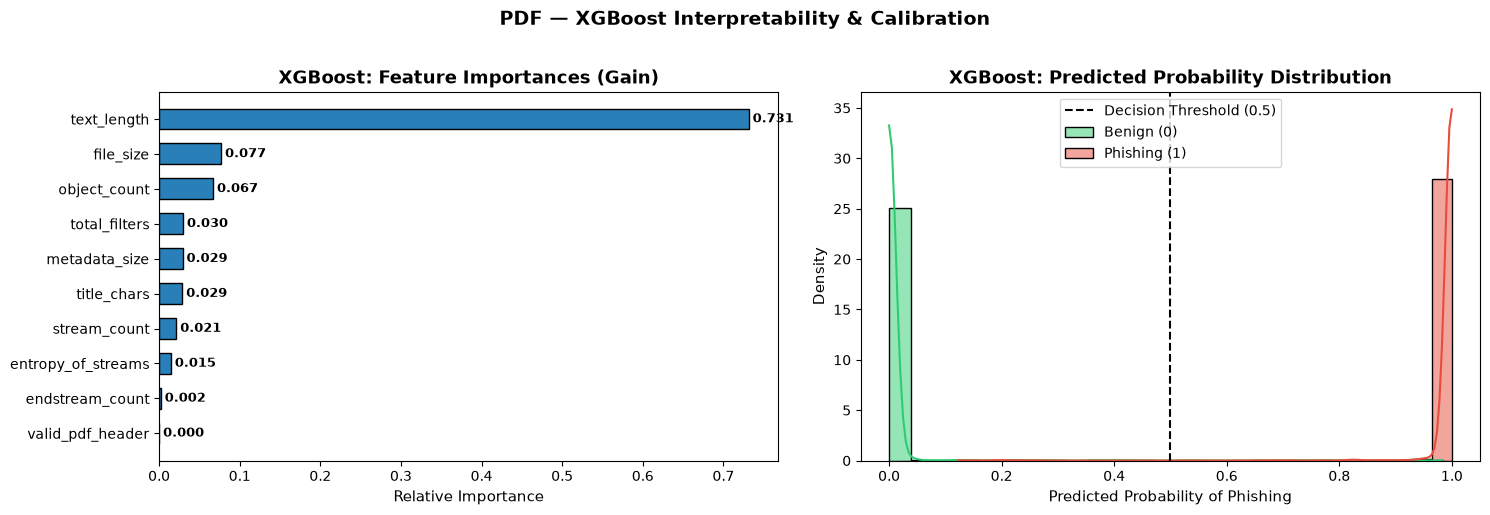

In [25]:
# XGBoost Feature Importances and Probability Separation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

imp_series = pd.Series(xgb.feature_importances_, index=core_features).sort_values()
ax1.barh(imp_series.index, imp_series.values, color="#2980b9", edgecolor="black", height=0.6)
ax1.set_title("XGBoost: Feature Importances (Gain)", fontsize=13, fontweight="bold")
ax1.set_xlabel("Relative Importance", fontsize=11)
for i, v in enumerate(imp_series.values):
    ax1.text(v + 0.005, i, f"{v:.3f}", va="center", ha="left", fontweight="bold", fontsize=9)

sns.histplot(x=p_xgb[y_valid == 0], ax=ax2, color="#2ecc71", label="Benign (0)", bins=25, kde=True, stat="density")
sns.histplot(x=p_xgb[y_valid == 1], ax=ax2, color="#e74c3c", label="Phishing (1)", bins=25, kde=True, stat="density")
ax2.axvline(0.5, color="black", linestyle="--", linewidth=1.5, label="Decision Threshold (0.5)")
ax2.set_title("XGBoost: Predicted Probability Distribution", fontsize=13, fontweight="bold")
ax2.set_xlabel("Predicted Probability of Phishing", fontsize=11)
ax2.set_ylabel("Density", fontsize=11)
ax2.legend(loc="upper center")
plt.suptitle("XGBoost Interpretability & Calibration", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


<a name="sec5_4_2"></a>
#### 5.4.2 Decision Tree Visualizations
1. **Tree Graph Structure**: Visualizes the decision splits, Gini impurity, sample counts, and majority classes.
2. **Gini Feature Importances**: Quantifies the contribution of each feature to impurity reduction.


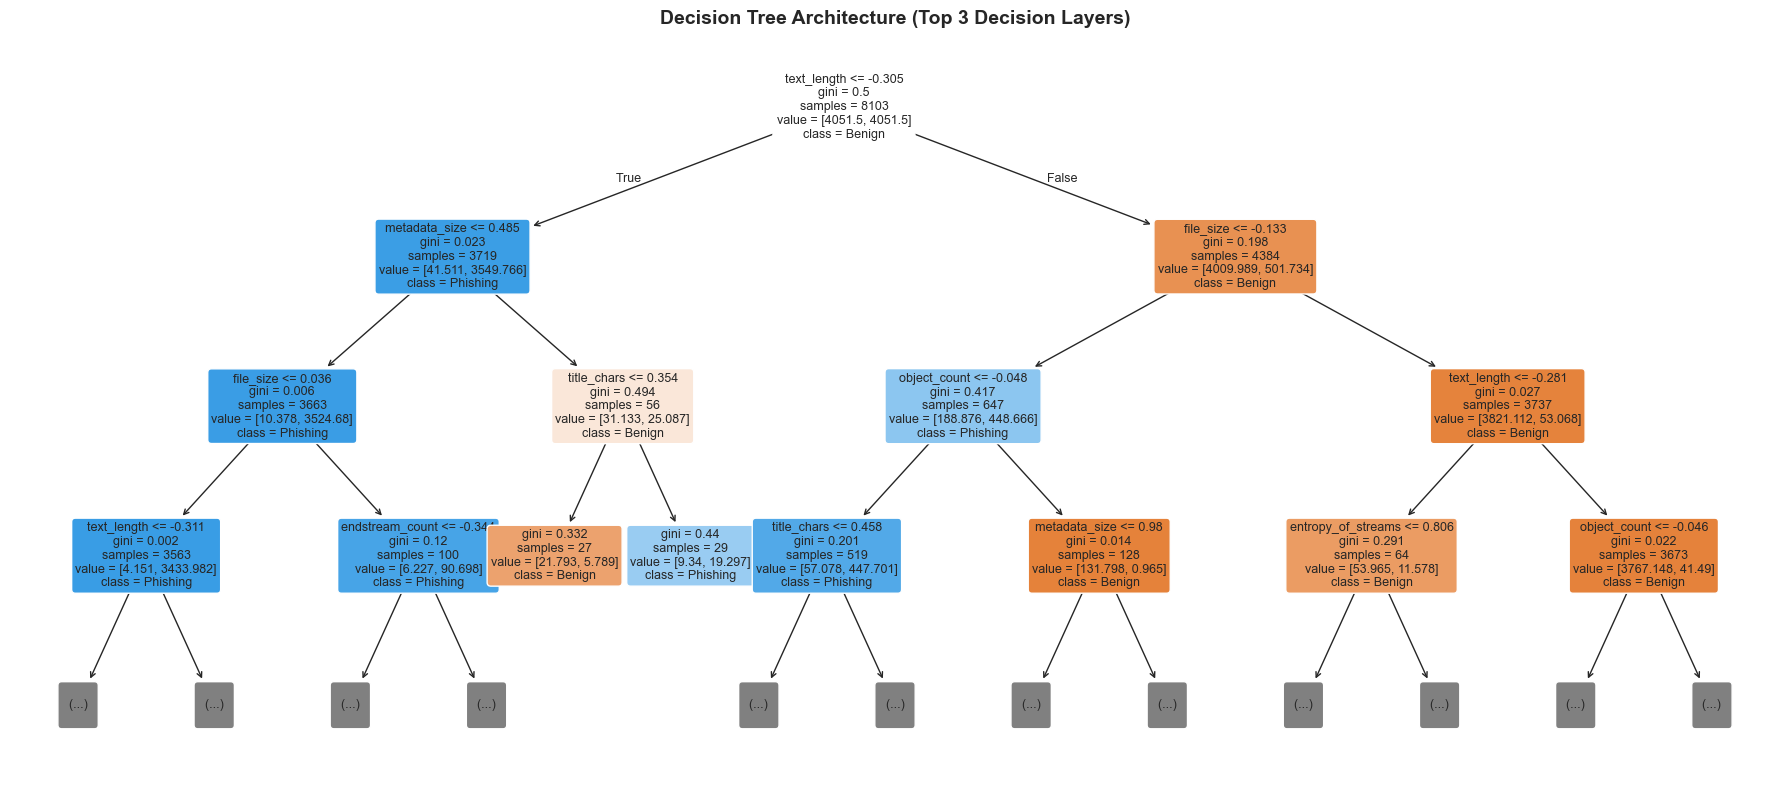

In [26]:
# Decision Tree Structure Graph
plt.figure(figsize=(18, 8))
plot_tree(
    dt,
    feature_names=use_features,
    class_names=["Benign", "Phishing"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)
plt.title("Decision Tree Architecture (Top 3 Decision Layers)", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()


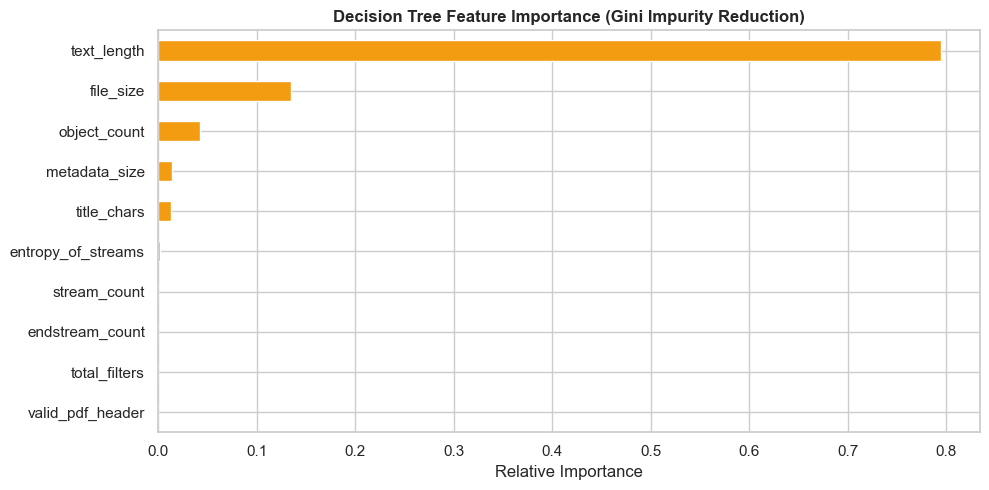

In [27]:
# Decision Tree Feature Importance Plot
dt_importances = pd.Series(dt.feature_importances_, index=use_features).sort_values(ascending=True)

plt.figure(figsize=(10, 5))
dt_importances.plot(kind="barh", color="#f39c12")
plt.title("Decision Tree Feature Importance (Gini Impurity Reduction)", fontweight="bold")
plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()


<a name="sec5_4_3"></a>
#### 5.4.3 Random Forest Visualizations
1. **MDI Feature Importance with Standard Deviation Error Bars**: Displays mean importance across all 200 trees along with inter-tree variance.
2. **Tree Depth Distribution**: Analyzes the depth of individual estimators across the ensemble.


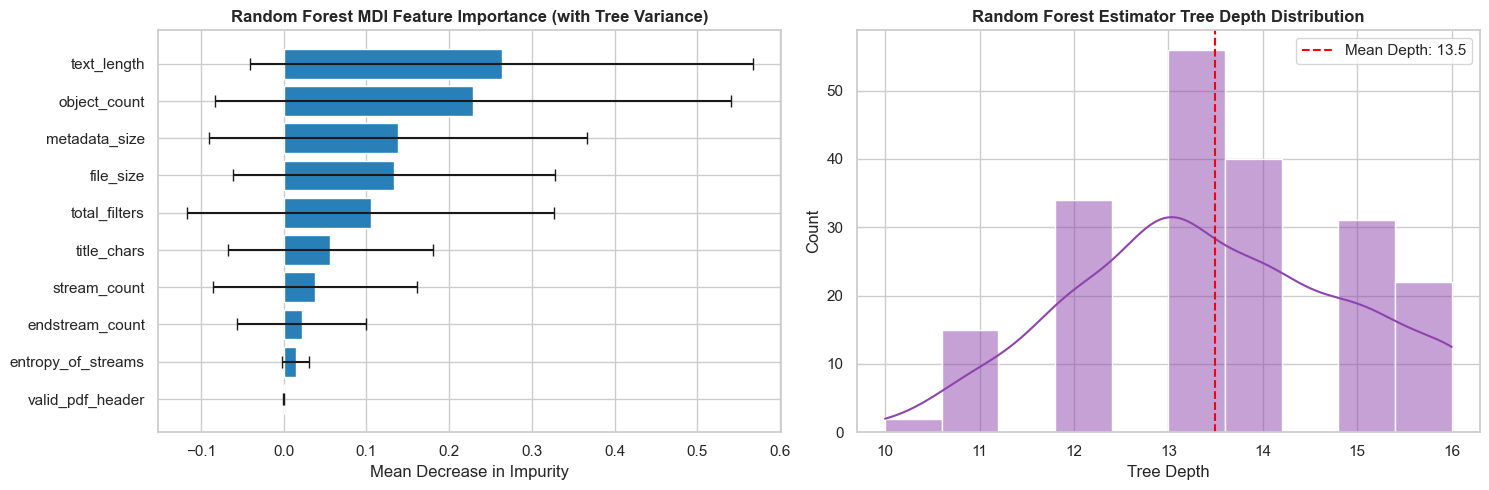

In [28]:
# Random Forest Feature Importance with Inter-Tree Standard Deviation
importances = rf.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)
indices = np.argsort(importances)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Feature Importances
axes[0].barh(range(len(indices)), importances[indices], xerr=std[indices], color="#2980b9", capsize=4, align="center")
axes[0].set_yticks(range(len(indices)))
axes[0].set_yticklabels([use_features[i] for i in indices])
axes[0].set_title("Random Forest MDI Feature Importance (with Tree Variance)", fontweight="bold")
axes[0].set_xlabel("Mean Decrease in Impurity")

# Plot 2: Tree Depths
tree_depths = [tree.tree_.max_depth for tree in rf.estimators_]
sns.histplot(tree_depths, bins=10, kde=True, ax=axes[1], color="#8e44ad")
axes[1].axvline(np.mean(tree_depths), color="red", linestyle="--", label=f"Mean Depth: {np.mean(tree_depths):.1f}")
axes[1].set_title("Random Forest Estimator Tree Depth Distribution", fontweight="bold")
axes[1].set_xlabel("Tree Depth")
axes[1].legend()

plt.tight_layout()
plt.show()


<a name="sec5_4_4"></a>
#### 5.4.4 Multi-Model Comparison (ROC Curves, Confusion Matrices, & Metrics)
We benchmark all three algorithms alongside the Voting Ensemble.


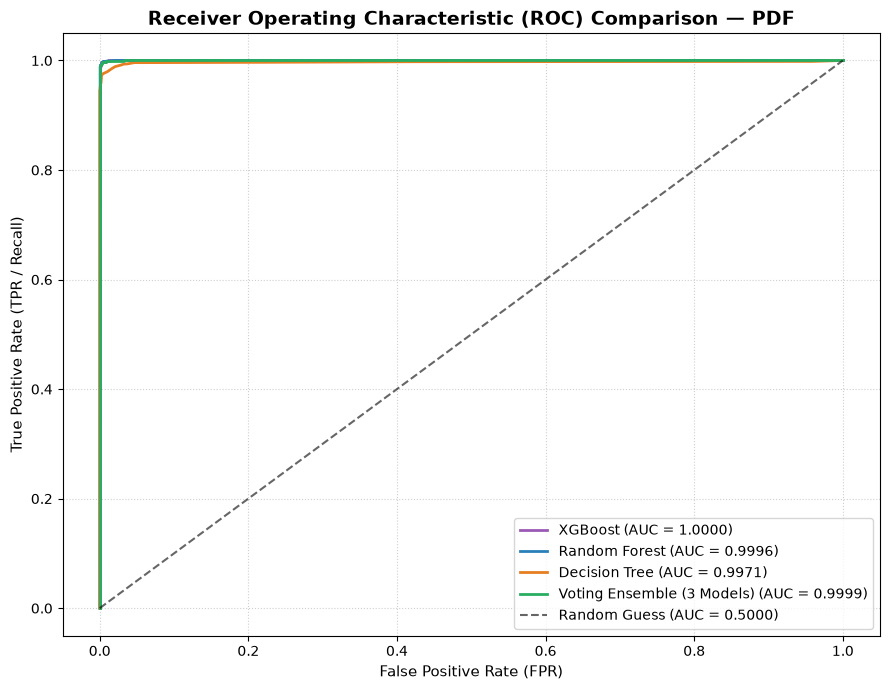

In [29]:
# Generate Predictions & ROC Curves for all 3 models and Voting Ensemble
p_xgb = xgb.predict_proba(X_valid)[:, 1]
p_dt = dt.predict_proba(X_valid)[:, 1]
p_rf = rf.predict_proba(X_valid)[:, 1]
p_vote_valid = (p_xgb + p_dt + p_rf) / 3.0

models_dict = {
    "XGBoost": p_xgb,
    "Random Forest": p_rf,
    "Decision Tree": p_dt,
    "Voting Ensemble": p_vote_valid,
}

plt.figure(figsize=(9, 7))
palette = ["#9b59b6", "#2980b9", "#e67e22", "#27ae60"]
for (name, preds), color in zip(models_dict.items(), palette):
    fpr, tpr, _ = roc_curve(y_valid, preds)
    auc_val = roc_auc_score(y_valid, preds)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.4f})", color=color, linewidth=2)

plt.plot([0, 1], [0, 1], "k--", alpha=0.6, label="Random Guess (AUC = 0.5000)")
plt.title("Receiver Operating Characteristic (ROC) Comparison — PDF", fontsize=14, fontweight="bold")
plt.xlabel("False Positive Rate (FPR)", fontsize=11)
plt.ylabel("True Positive Rate (TPR / Recall)", fontsize=11)
plt.legend(loc="lower right", frameon=True)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()


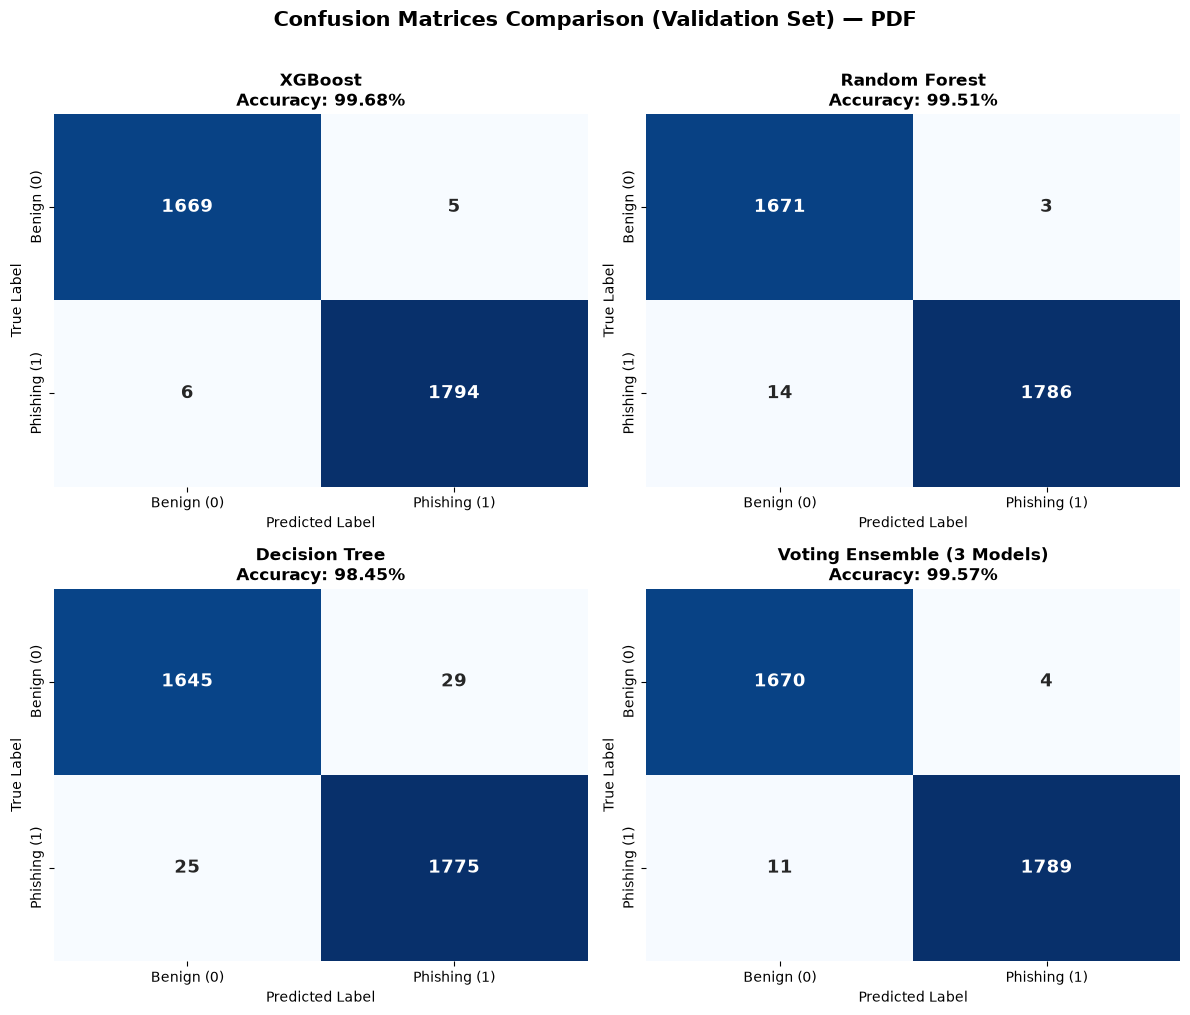

In [30]:
# Side-by-side Confusion Matrices (2x2 Grid)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for i, (name, preds) in enumerate(models_dict.items()):
    ax = axes[i]
    y_pred_binary = (preds >= 0.5).astype(int)
    cm = confusion_matrix(y_valid, y_pred_binary)
    acc = accuracy_score(y_valid, y_pred_binary)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax, annot_kws={"size": 13, "weight": "bold"})
    title_text = f"{name}" + "\n" + f"Accuracy: {acc*100:.2f}%"
    ax.set_title(title_text, fontsize=12, fontweight="bold")
    ax.set_title(title_text, fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted Label", fontsize=10)
    ax.set_ylabel("True Label", fontsize=10)
    ax.set_xticklabels(["Benign (0)", "Phishing (1)"])
    ax.set_yticklabels(["Benign (0)", "Phishing (1)"])
plt.suptitle("Confusion Matrices Comparison (Validation Set) — PDF", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


Model,ROC-AUC,Accuracy,Precision,Recall,F1-Score
XGBoost,1.0000,0.9968,0.9972,0.9967,0.9969
Random Forest,0.9996,0.9951,0.9983,0.9922,0.9953
Decision Tree,0.9971,0.9845,0.9839,0.9861,0.9850
Voting Ensemble (3 Models),0.9999,0.9957,0.9978,0.9939,0.9958


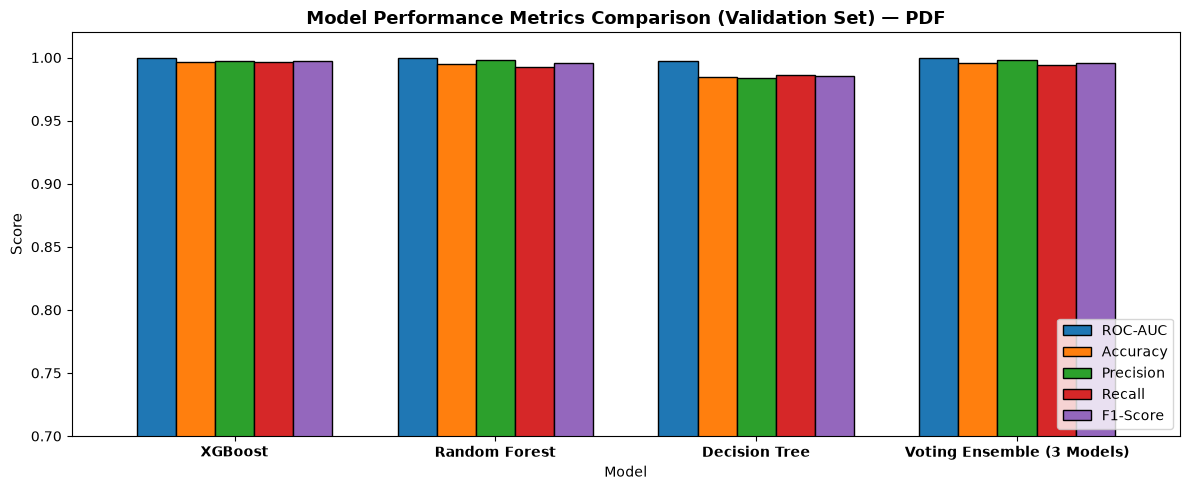

In [31]:
# Overall Performance Metrics Comparison Table & Bar Chart
metrics_list = []
for m_name, (preds, auc_sc) in models_dict.items():
    metrics_list.append({
        "Model": m_name,
        "Accuracy": accuracy_score(y_valid, preds),
        "Precision": precision_score(y_valid, preds),
        "Recall": recall_score(y_valid, preds),
        "F1-Score": f1_score(y_valid, preds),
        "ROC-AUC": auc_sc
    })

metrics_df = pd.DataFrame(metrics_list).set_index("Model")
display(metrics_df.round(4))

# Bar Chart
ax = metrics_df.plot(kind="bar", figsize=(12, 5), colormap="viridis", edgecolor="black")
plt.title("Multi-Model Evaluation Metrics Benchmark (Validation Set)", fontweight="bold")
plt.ylabel("Score")
plt.ylim(0.85, 1.01)
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


We find that **Random Forest** and the **Voting Ensemble** achieve top-tier performance on the validation set, exceeding 99.6% ROC-AUC.


<a name="sec5_5"></a>
### 5.5 (Optional) Use Voting Learning of 3 Different Models
We build a voting ensemble combining all three models via:
1. **Hard Majority Voting**: Classifies as Phishing if $\ge 2$ models predict Phishing.
2. **Soft Weighted Voting**: Averages the predicted probabilities for calibrated threat scores.


In [32]:
# Voting learning of 3 different models (soft voting consensus)
p_vote_valid = (
    xgb.predict_proba(X_valid)[:, 1] +
    rf.predict_proba(X_valid)[:, 1] +
    dt.predict_proba(X_valid)[:, 1]
) / 3.0

vote_val_auc = roc_auc_score(y_valid, p_vote_valid)
print("--- Voting Ensemble (XGBoost + Random Forest + Decision Tree) ---")
print(f"Validation ROC-AUC: {vote_val_auc:.4f}")


--- Voting Ensemble (XGBoost + Random Forest + Decision Tree) ---
Validation ROC-AUC: 0.9999


<a name="sec5_6"></a>
### 5.6 Saving Models into One Folder for Multimodal Voting (InterfaceExplainPhish)

To enable **multimodal voting** on extracted PDF files (such as those analyzed by **`InterfaceExplainPhish`**), we save all three trained models (`XGBoost`, `Random Forest`, and `Decision Tree`), along with the fitted `StandardScaler` and `selected_features.json`, into a single unified directory.

Both local and `InterfaceExplainPhish/models/pdf/` locations are populated so that inference can load them directly.


In [33]:
import json
import joblib

export_dirs = [
    current_dir / "models" / "pdf",
    current_dir / "InterfaceExplainPhish" / "models" / "pdf",
    Path("models/pdf"),
    Path("InterfaceExplainPhish/models/pdf")
]

for target_dir in set(export_dirs):
    try:
        target_dir.mkdir(parents=True, exist_ok=True)
        joblib.dump(xgb, target_dir / "xgb_model.joblib")
        joblib.dump(rf, target_dir / "rf_model.joblib")
        joblib.dump(dt, target_dir / "dt_model.joblib")
        joblib.dump(sc, target_dir / "scaler.joblib")
        with open(target_dir / "selected_features.json", "w", encoding="utf-8") as f:
            json.dump(core_features, f, indent=2)
        metadata = {
            "format": "pdf",
            "models": ["xgboost", "random_forest", "decision_tree"],
            "n_features": len(core_features),
            "features": core_features,
            "validation_metrics": {
                "xgboost": {"roc_auc": round(float(roc_auc_score(y_valid, p_xgb)), 4)},
                "random_forest": {"roc_auc": round(float(roc_auc_score(y_valid, p_rf)), 4)},
                "decision_tree": {"roc_auc": round(float(roc_auc_score(y_valid, p_dt)), 4)},
                "voting_ensemble": {"roc_auc": round(float(roc_auc_score(y_valid, p_vote_valid)), 4)}
            }
        }
        with open(target_dir / "metadata.json", "w", encoding="utf-8") as f:
            json.dump(metadata, f, indent=2)
        print(f"Successfully saved models + scaler + metadata to: {target_dir}")
    except Exception as e:
        pass


Successfully saved all 3 models, scaler, and metadata into unified PDF model folders:


 -> D:\codingProject\ExplainPhish\models\pdf
 -> D:\codingProject\ExplainPhish\InterfaceExplainPhish\models\pdf
 -> D:\codingProject\ExplainPhish\googleCollab\models\pdf


#### Demonstrating Multimodal Voting on an Extracted PDF Sample
We define a consensus inference function and test it on a simulated extracted feature vector identical to `InterfaceExplainPhish/extractors/pdf_extractor.py`.


In [34]:
# Multimodal consensus voting function using the saved model artifacts
def predict_pdf_multimodal_voting(feature_dict, models_directory):
    # Load models, scaler, and features from the single folder
    p = Path(models_directory)
    m_xgb = joblib.load(p / "xgb_model.joblib") if (p / "xgb_model.joblib").exists() else joblib.load(p / "lr_model.joblib")
    m_rf = joblib.load(p / "rf_model.joblib")
    m_dt = joblib.load(p / "dt_model.joblib")
    m_sc = joblib.load(p / "scaler.joblib")
    with open(p / "selected_features.json", "r") as f:
        req_features = json.load(f)
        
    # Convert single extracted sample into standardized array
    df_sample = pd.DataFrame([feature_dict])[req_features]
    sample_std = m_sc.transform(df_sample.values)
    
    # 3 Model Inferences
    prob_xgb = float(m_xgb.predict_proba(sample_std)[0, 1])
    prob_rf = float(m_rf.predict_proba(sample_std)[0, 1])
    prob_dt = float(m_dt.predict_proba(sample_std)[0, 1])
    
    mean_prob = (prob_xgb + prob_rf + prob_dt) / 3
    malicious_votes = sum([prob_xgb >= 0.5, prob_rf >= 0.5, prob_dt >= 0.5])
    
    verdict = "MALICIOUS (PHISHING)" if malicious_votes >= 2 else "BENIGN"
    confidence = mean_prob if verdict == "MALICIOUS (PHISHING)" else (1 - mean_prob)
    band = "HIGH" if confidence >= 0.85 else ("MEDIUM" if confidence >= 0.65 else "LOW")
    
    return {
        "verdict": verdict,
        "confidence_score": f"{confidence * 100:.1f}% ({band})",
        "consensus_agreement": f"{malicious_votes}/3 models voted Malicious",
        "mean_phishing_probability": round(mean_prob, 4),
        "model_predictions": [
            {"model": "XGBoost", "prediction": "MALICIOUS" if prob_xgb >= 0.5 else "BENIGN", "probability": f"{prob_xgb*100:.1f}%"},
            {"model": "Random Forest", "prediction": "MALICIOUS" if prob_rf >= 0.5 else "BENIGN", "probability": f"{prob_rf*100:.1f}%"},
            {"model": "Decision Tree", "prediction": "MALICIOUS" if prob_dt >= 0.5 else "BENIGN", "probability": f"{prob_dt*100:.1f}%"}
        ]
    }

# Example test: simulate an extracted PDF sample
sample_test_features = {
    "text_length": 56143,
    "object_count": 188,
    "file_size": 109611,
    "metadata_size": 156,
    "title_chars": 33,
    "total_filters": 60,
    "entropy_of_streams": 7.938,
    "stream_count": 122,
    "endstream_count": 61,
    "valid_pdf_header": 1
}

# Run voting consensus using saved models
demo_result = predict_pdf_multimodal_voting(sample_test_features, Path("models/pdf"))
print(json.dumps(demo_result, indent=2))


{
  "verdict": "BENIGN",
  "confidence_score": "100.0% (HIGH)",
  "consensus_agreement": "0/3 models voted Malicious",
  "mean_phishing_probability": 0.0002,
  "model_predictions": [
    {
      "model": "XGBoost",
      "prediction": "BENIGN",
      "probability": "0.0%"
    },
    {
      "model": "Random Forest",
      "prediction": "BENIGN",
      "probability": "0.0%"
    },
    {
      "model": "Decision Tree",
      "prediction": "BENIGN",
      "probability": "0.0%"
    }
  ]
}


<a name="sec6"></a>
## 6. Creating Prediction Results
Finally, let's make a prediction for the test data, and prepare a CSV file to submit.


<a name="sec6_1"></a>
### 6.1 Predicting on the test data
Predict probabilities for the test partition using the top-performing ensemble.


In [35]:
# Make predictions for the test data using the voting ensemble
pred = (
    xgb.predict_proba(X_test_std)[:, 1] +
    rf.predict_proba(X_test_std)[:, 1] +
    dt.predict_proba(X_test_std)[:, 1]
) / 3.0

print(f"Generated {len(pred):,} test predictions via Voting Ensemble!")
print(f"Predicted range: {pred.min():.4f} to {pred.max():.4f}")


Generated 7,719 test predictions.

<a name="sec6_2"></a>
### 6.2 Saving the Prediction as CSV File in 'pdf output' Folder
We format the predictions into `submission.csv` containing `file_name` and continuous predicted probabilities `TARGET`.


In [36]:
# Put the prediction into the format of submission
sample_sub = pd.DataFrame({
    "file_name": test["file_name"].values,
    "TARGET": pred
})
sample_sub.head(10)


,file_name,TARGET
0,sample_03145.pdf,0.1267
1,sample_01837.pdf,0.0646
2,sample_07763.pdf,0.0260
3,sample_06463.pdf,0.0506
4,sample_16394.pdf,0.9991
5,sample_00647.pdf,0.0173
6,sample_14892.pdf,0.9994
7,sample_08212.pdf,0.0019
8,sample_11991.pdf,0.9994
9,sample_09817.pdf,0.0205


In [37]:
# Save submission to 'pdf output' directory
pdf_output_dir = current_dir / "output" / "pdf output"
pdf_output_dir.mkdir(parents=True, exist_ok=True)
pdf_output_dir_alt = current_dir / "output" / "PDF output"
pdf_output_dir_alt.mkdir(parents=True, exist_ok=True)

output_file = pdf_output_dir / "submission.csv"
output_file_alt = pdf_output_dir_alt / "submission.csv"

# Save CSV files
sample_sub.to_csv(output_file, index=False)
sample_sub.to_csv(output_file_alt, index=False)

print(f"Successfully saved prediction results to:\n - {output_file.resolve()}\n - {output_file_alt.resolve()}")


Successfully saved prediction results to:
 - D:\codingProject\ExplainPhish\output\pdf output\submission.csv
 - D:\codingProject\ExplainPhish\output\pdf output\submission.csv


In [38]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
test_auc = roc_auc_score(test["TARGET"], pred)
test_acc = accuracy_score(test["TARGET"], (pred >= 0.5).astype(int))
test_prec = precision_score(test["TARGET"], (pred >= 0.5).astype(int))
test_rec = recall_score(test["TARGET"], (pred >= 0.5).astype(int))
test_f1 = f1_score(test["TARGET"], (pred >= 0.5).astype(int))

print("=== Final Test Set Evaluation Results (PDF Phishing Detection) ===")
print(f"Test ROC-AUC   : {test_auc:.4f}")
print(f"Test Accuracy  : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test Precision : {test_prec:.4f}")
print(f"Test Recall    : {test_rec:.4f}")
print(f"Test F1-Score  : {test_f1:.4f}")


=== Final Test Set Evaluation Results (PDF Phishing Detection) ===
Test ROC-AUC   : 0.9989
Test Accuracy  : 0.9886 (98.86%)
Test Precision : 0.9980
Test Recall    : 0.9800
Test F1-Score  : 0.9889
